# Uniform state preparation

**Download Notebook** - {nb-download}`state_preparation.ipynb`

`uniform_state(L)` prepares equal amplitudes on the first $L$ basis states:

$$
|u_L\rangle=\frac{1}{\sqrt L}\sum_{j=0}^{L-1}|j\rangle,
\qquad n=\lceil\log_2L\rceil.
$$

The same interface works whether or not $L$ is a power of two. This notebook compares $L=4$ and $L=6$, checks their statevectors, and shows the resulting probabilities.

Run from a source checkout with the development dependencies installed. The repository default is little endian.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from guppylang import guppy
from guppylang.std.quantum import discard_array
from guppylang.std.debug import state_output
from selene_sim import Quest

from guppyalgos.primitives.state_preparation import uniform_state
from guppyalgos.primitives.arithmetic.comparator import comparator_ripple_cuccaro
from guppyalgos.primitives.gate_decompositions.cnx.cnx import cnx
from guppyalgos.utils import qarray
from guppyalgos.testing import assert_allclose_ignorephase, switch_endianness

## 1. Four states: Hadamards are enough

For $L=4$, two qubits span exactly the required states:

$$
|u_4\rangle=H^{\otimes2}|00\rangle
=\tfrac12(|00\rangle+|01\rangle+|10\rangle+|11\rangle).
$$

The factory chooses the Hadamard implementation. Start `qreg` at zero and pass it to the returned function.

In [2]:
prepare_four = uniform_state(4)


@guppy
def four_states() -> None:
    qreg = qarray(2)
    prepare_four(qreg)
    state_output("result_state", qreg)
    discard_array(qreg)


result = four_states.emulator(2).with_seed(42).run()
state = Quest.extract_states_dict(result.results[0].entries)["result_state"]
amplitudes_four = switch_endianness(state.get_single_state())
assert_allclose_ignorephase(amplitudes_four, np.ones(4) / 2)
print("All four amplitudes match 1/2, up to global phase.")

All four amplitudes match 1/2, up to global phase.


## 2. Six states: exclude unused addresses

For $L=6$, three qubits provide eight addresses, but the last two must have zero amplitude:

$$
|u_6\rangle=\frac1{\sqrt6}\sum_{j=0}^{5}|j\rangle,
\qquad \Pr(j)=\begin{cases}1/6&j<6,\\0&j\geq6.\end{cases}
$$

The factory uses a comparator to identify valid addresses and amplitude amplification to prepare the state. The optional `cnx_box` and `comparator_box` arguments select the underlying implementations; omitting them uses these same defaults.

In [3]:
L = 6
n = int(np.ceil(np.log2(L)))
prepare_six = uniform_state(
    L, cnx_box=cnx, comparator_box=comparator_ripple_cuccaro,
)


@guppy
def six_states() -> None:
    qreg = qarray(n)
    prepare_six(qreg)
    state_output("result_state", qreg)
    discard_array(qreg)


# Reserve simulator qubits for the comparator and amplification workspace.
result = six_states.emulator(2 * n + 5).with_seed(42).run()
state = Quest.extract_states_dict(result.results[0].entries)["result_state"]
amplitudes_six = switch_endianness(state.get_single_state())
expected = np.zeros(2**n)
expected[:L] = 1 / np.sqrt(L)
assert_allclose_ignorephase(amplitudes_six, expected)
print("The first six amplitudes match 1/sqrt(6); the remaining two are zero.")

The first six amplitudes match 1/sqrt(6); the remaining two are zero.


## Compare the probabilities

The assertions check the complex amplitudes, including their relative phases. The bars show their squared magnitudes, $\Pr(j)=|\langle j|u_L\rangle|^2$. These are exact simulator probabilities, rather than finite-shot estimates.

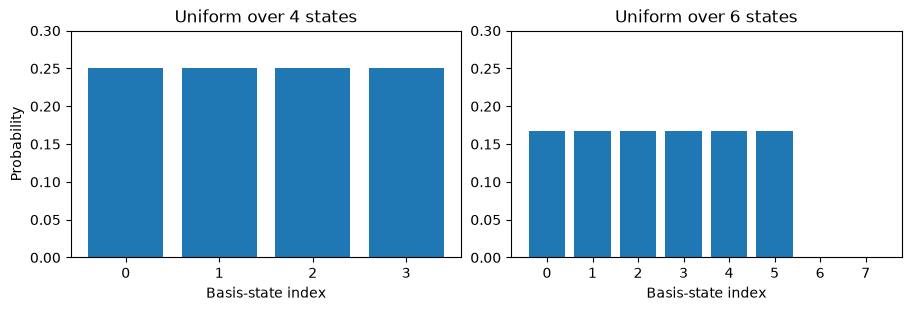

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
for axis, (length, amplitudes) in zip(axes, [(4, amplitudes_four), (6, amplitudes_six)]):
    axis.bar(np.arange(len(amplitudes)), np.abs(amplitudes)**2)
    axis.set(title=f"Uniform over {length} states", xlabel="Basis-state index",
             xticks=np.arange(len(amplitudes)), ylim=(0, 0.3))
axes[0].set_ylabel("Probability")
plt.show()

To reverse a preparation, build its inverse with `uniform_state(L, dagger=True)`. Additional workspace is internal to the preparation routine; the calling circuit keeps the same `qreg` interface.